# Project 18: Baseline RL Agent Implementation
**Evolutionary Reward Shaping for Reinforcement Learning Agents**

This notebook implements and evaluates baseline reinforcement learning (RL) agents across three environments:

| Environment | Algorithm |
|---|---|
| CartPole-v1 (Gymnasium) | DQN via Stable Baselines3 |
| LunarLander-v3 (Gymnasium) | DQN via Stable Baselines3 |
| MiniGrid-Empty-5x5-v0 | DQN via Stable Baselines3 + Tabular Q-Learning |

All episode rewards and lengths are logged to CSV files and learning curves are plotted at the end of each section.

---

## Running this notebook

**Locally (recommended):** Dependencies are managed via `requirements.txt` in the project root. If you have not yet set up the environment, follow the instructions in `README.md`. No changes to this notebook are needed.

**Google Colab:** Uncomment and run the installation cell in Section 1 before running anything else. After installation, restart the Colab runtime (Runtime > Restart runtime), then run all cells from Section 2 onwards. No other changes are needed.

---

## **1. Installation (Colab Only)**

**Local Users:** Skip this cell entirely; dependencies are already installed in your virtual environment.

**Colab Users:** Uncomment the line below, run this cell, then restart the runtime before continuing.

In [3]:
# COLAB ONLY — uncomment the line below if running on Google Colab
# After running, go to Runtime > Restart runtime, then continue from Section 2

# %pip install stable-baselines3[extra] gymnasium[box2d] minigrid --quiet

## **2. Imports and Configuration**

In [4]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
import warnings
import random
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from minigrid.wrappers import FlatObsWrapper
from matplotlib.ticker import FuncFormatter

print('All Imports Successful.')

objc[54984]: Class SDLApplication is implemented in both /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/.venv/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1639b4890) and /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/.venv/lib/python3.11/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1652212c8). One of the two will be used. Which one is undefined.
objc[54984]: Class SDLAppDelegate is implemented in both /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/.venv/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1639b48e0) and /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/.venv/lib/python3.11/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x165221318). One of the two will be used. Which one is undefined.
objc[54984]: Class SDLTranslatorResponder is implemented in both /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/.venv/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1639b4958) and /Users/rpg

All Imports Successful.


### 2.1 Path Configuration

This cell resolves the correct paths for saving logs and results regardless of whether the notebook is being run locally or on Colab.

- **Locally:** The notebook lives in `notebooks/`, so the project root is one level up. Logs and results are saved to `logs/` and `results/` at the project root.
- **Colab:** There is no project root structure, so logs and results are saved to `./logs` and `./results` relative to the notebook.

No changes needed here — this cell handles both cases automatically.

In [5]:
def _is_colab() -> bool:
  """Returns True if the notebook is running on Google Colab."""
  try:
    import google.colab
    return True
  except ImportError:
    return False


if _is_colab():
  PROJECT_ROOT = pathlib.Path('.')
  print('Environment: Google Colab')
else:
  _cwd = pathlib.Path().resolve()
  PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
  print(f'Environment: Local | Project Root: {PROJECT_ROOT}')

LOG_DIRECTORY = str(PROJECT_ROOT / 'logs')
RESULTS_DIRECTORY = str(PROJECT_ROOT / 'results')

os.makedirs(LOG_DIRECTORY, exist_ok=True)
os.makedirs(RESULTS_DIRECTORY, exist_ok=True)

print(f'Log Directory : {LOG_DIRECTORY}')
print(f'Results Directory: {RESULTS_DIRECTORY}')

Environment: Local | Project Root: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward
Log Directory : /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/logs
Results Directory: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results


### 2.2 Global Settings

In [6]:
# Plotting style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Random seed used throughout for reproducibility
# Change this value to run with a different seed
SEED = 24

print(f'Random Seed: {SEED}')

Random Seed: 24


---
## **3. Shared Utilities**

These utilities are shared across all environments and agents. Run this section once before running any training cells.

### 3.1 Episode Reward Callback

A custom SB3 callback that records episode rewards and lengths during training. SB3's `Monitor` wrapper stores episode statistics in the `info` dictionary at the end of each episode — this callback extracts and stores them for later analysis.

In [7]:
class EpisodeLoggerCallback(BaseCallback):
  """
  Logs episode rewards and lengths at the end of every episode.
  Accessible via self.episode_rewards and self.episode_lengths after training.
  """
  def __init__(self, verbose=0):
    super().__init__(verbose)
    self.episode_rewards = []
    self.episode_lengths = []

  def _on_step(self) -> bool:
    infos = self.locals.get('infos', [])
    for info in infos:
      if 'episode' in info:
        self.episode_rewards.append(info['episode']['r'])
        self.episode_lengths.append(info['episode']['l'])
    return True

### 3.2 Logging and Plotting Utilities

In [8]:
def save_results_to_csv(episode_rewards, episode_lengths, env_name, agent_name):
  """
  Saves episode rewards and lengths to a CSV file.
  File is written to RESULTS_DIRECTORY/{env_name}_{agent_name}_results.csv
  Returns the resulting DataFrame.
  """
  df = pd.DataFrame({
    'episode': np.arange(1, len(episode_rewards) + 1),
    'reward': episode_rewards,
    'length': episode_lengths
  })
  filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_results.csv')
  df.to_csv(filename, index=False)
  print(f'Results Saved To: {filename}')
  return df


def print_summary(episode_rewards, env_name, agent_name):
  """
  Prints a statistical summary of episode rewards.
  """
  rewards = np.array(episode_rewards)
  print(f'\n=== {agent_name} on {env_name} ===')
  print(f'  Episodes Completed : {len(rewards)}')
  print(f'  Mean Reward : {rewards.mean():.2f}')
  print(f'  Std Reward : {rewards.std():.2f}')
  print(f'  Min Reward : {rewards.min():.2f}')
  print(f'  Max Reward : {rewards.max():.2f}')
  print(f'  Final 10-Ep Mean : {rewards[-10:].mean():.2f}')


def plot_learning_curve(episode_rewards, env_name, agent_name, window=20, save=True):
  """
  Plots raw episode rewards and a rolling mean learning curve.
  Saves the figure to RESULTS_DIRECTORY if save=True.
  """
  episodes = np.arange(1, len(episode_rewards) + 1)
  rewards = np.array(episode_rewards)
  rolling_mean = pd.Series(rewards).rolling(window=window, min_periods=1).mean()

  fig, ax = plt.subplots()
  ax.plot(episodes, rewards, alpha=0.3, color='steelblue', label='Episode Reward')
  ax.plot(episodes, rolling_mean, color='steelblue', linewidth=2, label=f'Rolling Mean (Window={window})')
  ax.set_xlabel('Episode')
  ax.set_ylabel('Cumulative Reward')
  ax.set_title(f'{agent_name} on {env_name} - Learning Curve')
  ax.legend()
  plt.tight_layout()

  if save:
    filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_learning_curve.png')
    fig.savefig(filename, dpi=150)
    print(f'Figure Saved To: {filename}')

  plt.show()


print('Utilities Loaded.')

Utilities Loaded.


---
## **4. CartPole-v1 - DQN Baseline**

CartPole-v1 tasks the agent with balancing a pole attached to a cart by applying left or right forces. The episode terminates when the pole angle exceeds 12 degrees or the cart moves more than 2.4 units from the centre. A reward of +1 is given for every timestep the pole remains upright, and the maximum possible episode reward is 500.

This is a well-understood environment that DQN typically solves within 100,000 timesteps, making it a reliable first test of the training pipeline.

In [9]:
# Training duration - increase for more thorough training
CARTPOLE_TIMESTEPS = 200_000

cartpole_log_dir = os.path.join(LOG_DIRECTORY, 'cartpole')
os.makedirs(cartpole_log_dir, exist_ok=True)
cartpole_env = Monitor(gym.make('CartPole-v1'), cartpole_log_dir)

cartpole_callback = EpisodeLoggerCallback()
cartpole_agent = DQN(
  policy='MlpPolicy',
  env=cartpole_env,
  learning_rate=1e-3,
  buffer_size=500_000,
  learning_starts=1000,
  batch_size=64,
  gamma=0.99,
  train_freq=256,
  gradient_steps=-1,
  target_update_interval=500,
  exploration_fraction=0.1,
  exploration_final_eps=0.05,
  policy_kwargs=dict(net_arch=[256, 256]),
  verbose=0,
  seed=SEED
)

print(f'Training DQN on CartPole-v1 for {CARTPOLE_TIMESTEPS:,} timesteps...')
cartpole_agent.learn(
  total_timesteps=CARTPOLE_TIMESTEPS,
  callback=cartpole_callback,
  progress_bar=True
)
cartpole_env.close()
print('Training Complete.')

Output()

Training DQN on CartPole-v1 for 200,000 timesteps...


Training Complete.


Results Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/CartPole-v1_DQN_results.csv

=== DQN on CartPole-v1 ===
  Episodes Completed : 1759
  Mean Reward : 113.77
  Std Reward : 123.28
  Min Reward : 9.00
  Max Reward : 500.00
  Final 10-Ep Mean : 222.50
Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/CartPole-v1_DQN_learning_curve.png


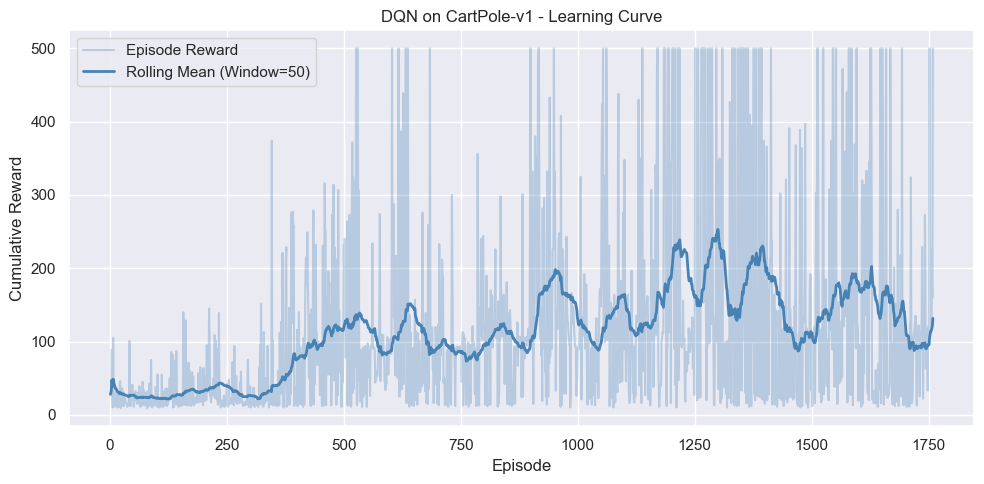

In [10]:
cartpole_df = save_results_to_csv(
  cartpole_callback.episode_rewards,
  cartpole_callback.episode_lengths,
  'CartPole-v1', 'DQN'
)
print_summary(cartpole_callback.episode_rewards, 'CartPole-v1', 'DQN')
plot_learning_curve(cartpole_callback.episode_rewards, 'CartPole-v1', 'DQN', window=50)

---
## **5. LunarLander-v3 - DQN Baseline**

LunarLander-v3 tasks the agent with landing a spacecraft on a designated landing pad using four discrete actions: do nothing, fire the left engine, fire the main engine, or fire the right engine. The agent receives positive rewards for moving towards the pad and landing successfully, and penalties for crashing or for excessive engine use. An episode score above 200 is generally considered a successful landing.

This environment is considerably harder than CartPole and typically requires 200,000+ timesteps for DQN to produce competent behaviour.

> **Note for Colab Users:** This cell may take 10 to 20 minutes on a CPU runtime, so switching to a GPU runtime for faster training is strongly advised (Runtime > Change runtime type > T4 GPU).

In [11]:
# Training Duration Note - LunarLander requires significantly more training than CartPole
LUNARLANDER_TIMESTEPS = 3_000_000

lunarlander_log_directory = os.path.join(LOG_DIRECTORY, 'lunarlander')
os.makedirs(lunarlander_log_directory, exist_ok=True)
lunarlander_env = Monitor(gym.make('LunarLander-v3'), lunarlander_log_directory)

lunarlander_callback = EpisodeLoggerCallback()
lunarlander_agent = DQN(
  policy='MlpPolicy',
  env=lunarlander_env,
  learning_rate=1e-3,
  buffer_size=1_000_000,
  learning_starts=10_000,
  batch_size=128,
  gamma=0.99,
  train_freq=4,
  target_update_interval=1000,
  exploration_fraction=0.12,
  exploration_final_eps=0.05,
  verbose=0,
  seed=SEED
)

print(f'Training DQN on LunarLander-v3 for {LUNARLANDER_TIMESTEPS:,} Timesteps...')
lunarlander_agent.learn(
  total_timesteps=LUNARLANDER_TIMESTEPS,
  callback=lunarlander_callback,
  progress_bar=True
)
lunarlander_env.close()
print('Training Complete.')

Output()

Training DQN on LunarLander-v3 for 3,000,000 Timesteps...


Training Complete.


Results Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/LunarLander-v3_DQN_results.csv

=== DQN on LunarLander-v3 ===
  Episodes Completed : 15255
  Mean Reward : -162.73
  Std Reward : 352.25
  Min Reward : -2097.87
  Max Reward : 321.56
  Final 10-Ep Mean : -633.63
Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/LunarLander-v3_DQN_learning_curve.png


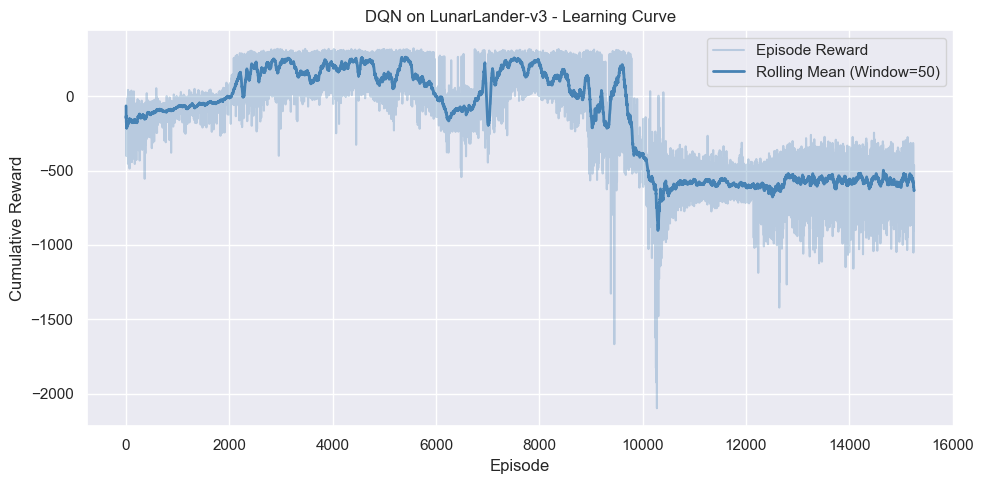

In [12]:
lunarlander_df = save_results_to_csv(
  lunarlander_callback.episode_rewards,
  lunarlander_callback.episode_lengths,
  'LunarLander-v3', 'DQN'
)
print_summary(lunarlander_callback.episode_rewards, 'LunarLander-v3', 'DQN')
plot_learning_curve(lunarlander_callback.episode_rewards, 'LunarLander-v3', 'DQN', window=50)

---
## **6. MiniGrid-Empty-5x5-v0 - DQN Baseline**

MiniGrid provides a family of partially observable grid-world environments with goal-oriented tasks. The Empty-5x5 environment places the agent in a small empty room with a goal tile it must reach. The agent receives a reward based on how quickly it reaches the goal: `1 - 0.9 * (step_count / max_steps)`, meaning faster solutions receive higher rewards.

MiniGrid observations are dictionary-based by default, so a `FlatObsWrapper` is applied to convert them to a flat NumPy array compatible with SB3's `MlpPolicy`.

In [13]:
MINIGRID_ENV_ID = 'MiniGrid-Empty-5x5-v0'

# 250,000 timesteps needed for stable convergence on MiniGrid with DQN
# Initial runs at 100,000 showed the agent failing to consolidate learning
MINIGRID_DQN_TIMESTEPS = 500_000

minigrid_dqn_log_directory = os.path.join(LOG_DIRECTORY, 'minigrid_dqn')
os.makedirs(minigrid_dqn_log_directory, exist_ok=True)

# FlatObsWrapper converts MiniGrid's dict observation to a flat numpy array
minigrid_dqn_env = Monitor(
  FlatObsWrapper(gym.make(MINIGRID_ENV_ID)),
  minigrid_dqn_log_directory
)

minigrid_dqn_callback = EpisodeLoggerCallback()
minigrid_dqn_agent = DQN(
  policy='MlpPolicy',
  env=minigrid_dqn_env,
  learning_rate=5e-4,
  buffer_size=500_000,
  learning_starts=1000,
  batch_size=64,
  gamma=0.99,
  train_freq=4,
  target_update_interval=500,
  exploration_fraction=0.15,
  exploration_final_eps=0.05,
  verbose=0,
  seed=SEED
)

print(f'Training DQN on {MINIGRID_ENV_ID} for {MINIGRID_DQN_TIMESTEPS:,} Timesteps...')
minigrid_dqn_agent.learn(
  total_timesteps=MINIGRID_DQN_TIMESTEPS,
  callback=minigrid_dqn_callback,
  progress_bar=True
)
minigrid_dqn_env.close()
print('Training Complete.')

Output()

Training DQN on MiniGrid-Empty-5x5-v0 for 500,000 Timesteps...


Training Complete.


Results Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/MiniGrid-Empty-5x5-v0_DQN_results.csv

=== DQN on MiniGrid-Empty-5x5-v0 ===
  Episodes Completed : 39115
  Mean Reward : 0.88
  Std Reward : 0.22
  Min Reward : 0.00
  Max Reward : 0.95
  Final 10-Ep Mean : 0.86
Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/MiniGrid-Empty-5x5-v0_DQN_learning_curve.png


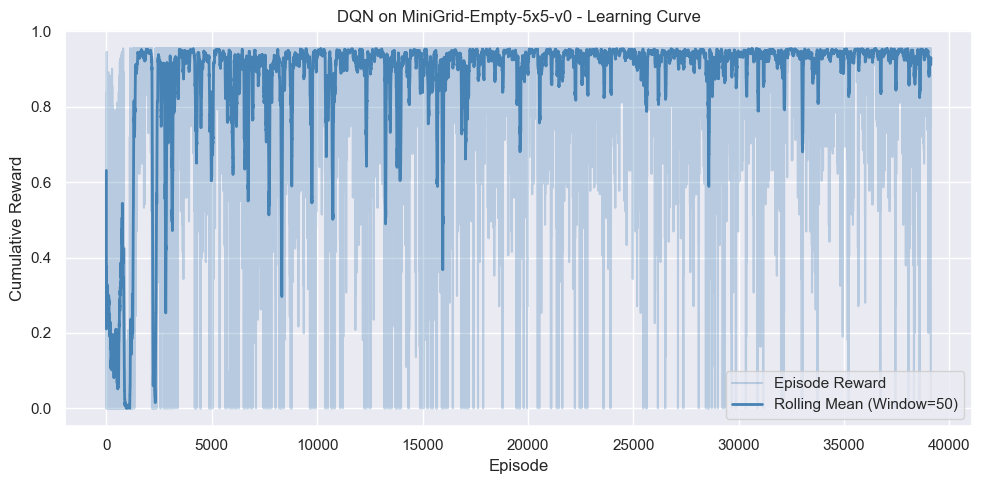

In [14]:
minigrid_dqn_df = save_results_to_csv(
  minigrid_dqn_callback.episode_rewards,
  minigrid_dqn_callback.episode_lengths,
  MINIGRID_ENV_ID, 'DQN'
)
print_summary(minigrid_dqn_callback.episode_rewards, MINIGRID_ENV_ID, 'DQN')
plot_learning_curve(minigrid_dqn_callback.episode_rewards, MINIGRID_ENV_ID, 'DQN', window=50)

---
## **7. MiniGrid-Empty-5x5-v0 - Tabular Q-Learning Baseline**

Tabular Q-learning maintains an explicit lookup table mapping state-action pairs to estimated action values. Unlike DQN, it does not use a neural network; it updates the Q-table directly using the Bellman equation after each step.

It is well-suited to small discrete environments like MiniGrid-Empty-5x5 where the full state space can be enumerated. SB3 does not include a tabular Q-learning implementation, so this is implemented from scratch.

The agent uses epsilon-greedy action selection: with probability epsilon it selects a random action (exploration), otherwise it selects the action with the highest estimated Q-value (exploitation). Epsilon decays over time so the agent gradually shifts from exploration to exploitation.

In [15]:
class TabularQLearningAgent:
  """
  Tabular Q-Learning agent using a dictionary as the Q-table.
  Keys are (state, action) tuples where state is derived from the flattened observation array.
  """
  def __init__(self, n_actions, learning_rate=0.1, gamma=0.99, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995):
    self.n_actions = n_actions
    self.lr = learning_rate
    self.gamma = gamma
    self.epsilon = epsilon_start
    self.epsilon_end = epsilon_end
    self.epsilon_decay = epsilon_decay
    self.q_table = {}

  def _state_key(self, obs):
    """Convert observation array to a hashable tuple key."""
    return tuple(obs.flatten().astype(int))

  def get_q(self, obs, action):
    """Return Q-value for a state-action pair, defaulting to 0.0."""
    return self.q_table.get((self._state_key(obs), action), 0.0)

  def select_action(self, obs):
    """Epsilon-greedy action selection."""
    if np.random.random() < self.epsilon:
      return np.random.randint(self.n_actions)
    q_values = [self.get_q(obs, a) for a in range(self.n_actions)]
    return int(np.argmax(q_values))

  def update(self, obs, action, reward, next_obs, terminated):
    """Q-Learning (off-policy TD) update rule."""
    current_q = self.get_q(obs, action)
    if terminated:
      target_q = reward
    else:
      next_q_values = [self.get_q(next_obs, a) for a in range(self.n_actions)]
      target_q = reward + self.gamma * max(next_q_values)
    self.q_table[(self._state_key(obs), action)] = (current_q + self.lr * (target_q - current_q))

  def decay_epsilon(self):
    """Decay exploration rate at the end of each episode."""
    self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)


print('TabularQLearningAgent Defined.')

TabularQLearningAgent Defined.


In [16]:
QLEARNING_EPISODES = 2000

ql_env = FlatObsWrapper(gym.make(MINIGRID_ENV_ID))
n_actions = ql_env.action_space.n

ql_agent = TabularQLearningAgent(
  n_actions=n_actions,
  learning_rate=0.1,
  gamma=0.99,
  epsilon_start=1.0,
  epsilon_end=0.05,
  epsilon_decay=0.995
)

ql_episode_rewards = []
ql_episode_lengths = []

np.random.seed(SEED)

print(f'Training Tabular Q-Learning on {MINIGRID_ENV_ID} for {QLEARNING_EPISODES} episodes...')

for episode in range(QLEARNING_EPISODES):
  obs, _ = ql_env.reset(seed=SEED + episode)
  episode_reward = 0
  episode_length = 0
  terminated = False
  truncated = False

  while not (terminated or truncated):
    action = ql_agent.select_action(obs)
    next_obs, reward, terminated, truncated, _ = ql_env.step(action)
    ql_agent.update(obs, action, reward, next_obs, terminated)
    obs = next_obs
    episode_reward += reward
    episode_length += 1

  ql_agent.decay_epsilon()
  ql_episode_rewards.append(episode_reward)
  ql_episode_lengths.append(episode_length)

  if (episode + 1) % 200 == 0:
    recent_mean = np.mean(ql_episode_rewards[-200:])
    print(f'  Episode {episode + 1:>4}/{QLEARNING_EPISODES} | '
          f'Mean Reward (last 200): {recent_mean:.4f} | '
          f'Epsilon: {ql_agent.epsilon:.3f} | '
          f'Q-table Entries: {len(ql_agent.q_table)}')

ql_env.close()
print('Training Complete.')

Training Tabular Q-Learning on MiniGrid-Empty-5x5-v0 for 2000 episodes...
  Episode  200/2000 | Mean Reward (last 200): 0.6749 | Epsilon: 0.367 | Q-table Entries: 180
  Episode  400/2000 | Mean Reward (last 200): 0.9238 | Epsilon: 0.135 | Q-table Entries: 180
  Episode  600/2000 | Mean Reward (last 200): 0.9414 | Epsilon: 0.050 | Q-table Entries: 180
  Episode  800/2000 | Mean Reward (last 200): 0.9423 | Epsilon: 0.050 | Q-table Entries: 180
  Episode 1000/2000 | Mean Reward (last 200): 0.9421 | Epsilon: 0.050 | Q-table Entries: 180
  Episode 1200/2000 | Mean Reward (last 200): 0.9425 | Epsilon: 0.050 | Q-table Entries: 180
  Episode 1400/2000 | Mean Reward (last 200): 0.9418 | Epsilon: 0.050 | Q-table Entries: 180
  Episode 1600/2000 | Mean Reward (last 200): 0.9423 | Epsilon: 0.050 | Q-table Entries: 180
  Episode 1800/2000 | Mean Reward (last 200): 0.9418 | Epsilon: 0.050 | Q-table Entries: 180
  Episode 2000/2000 | Mean Reward (last 200): 0.9434 | Epsilon: 0.050 | Q-table Entries: 

Results Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/MiniGrid-Empty-5x5-v0_QLearning_results.csv

=== Q-Learning on MiniGrid-Empty-5x5-v0 ===
  Episodes Completed : 2000
  Mean Reward : 0.91
  Std Reward : 0.13
  Min Reward : 0.00
  Max Reward : 0.95
  Final 10-Ep Mean : 0.94
Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/MiniGrid-Empty-5x5-v0_Q-Learning_learning_curve.png


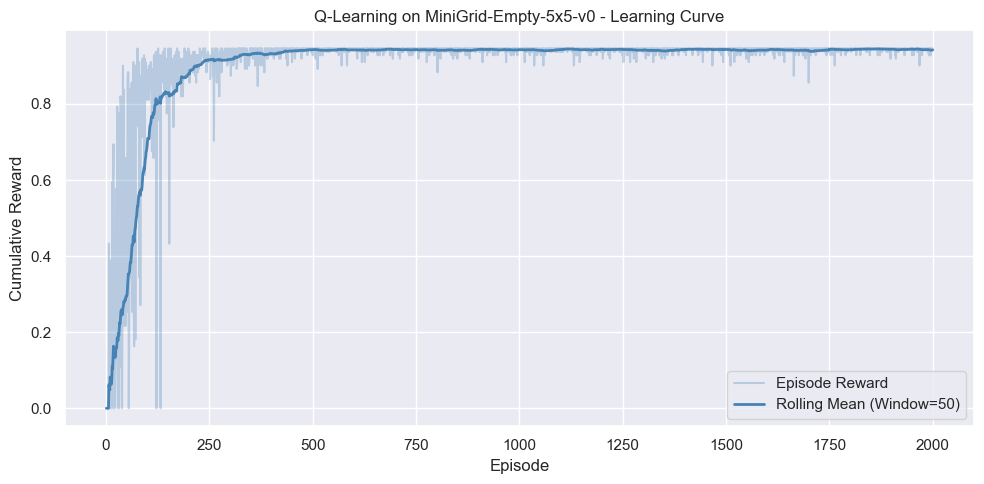

In [17]:
ql_df = save_results_to_csv(
  ql_episode_rewards,
  ql_episode_lengths,
  MINIGRID_ENV_ID, 'QLearning'
)
print_summary(ql_episode_rewards, MINIGRID_ENV_ID, 'Q-Learning')
plot_learning_curve(ql_episode_rewards, MINIGRID_ENV_ID, 'Q-Learning', window=50)

---
## **8. Comparisons and Summary**

This section lines up the baselines from the runs above on a common footing: comparative learning curves, then a small table and bar charts for convergence and stability.

Run it after Sections 4–7 so monitor logs and results CSVs are present. The cells below mirror the style of Section 3.2 (rolling means, saved figures under `results/`).

### 8.1 Comparative learning curves

DQN runs are read from Stable Baselines3 `Monitor` files under `logs/` (`r` = return, `l` = length in env steps). MiniGrid Q-learning uses the saved results CSV (`reward`, `length`), same schema as `save_results_to_csv` in Section 3.2.

- **Horizontal axis:** cumulative timesteps at each episode end (running sum of episode lengths), so curves are comparable in terms of environment experience.
- **Rolling means:** `rolling(window=w, min_periods=1)` on the reward series, as in `plot_learning_curve`, but two windows are plotted — 50 episodes in steelblue and 2000 episodes in vivid orange (`#ea580c`) so both short-horizon improvement and a smoother long-horizon level appear.

Figures are saved next to the per-environment learning curves from earlier sections.

Comparative learning curve: CartPole-v1 | DQN | 1759 episodes
Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/CartPole-v1_DQN_comparative_learning_curve.png


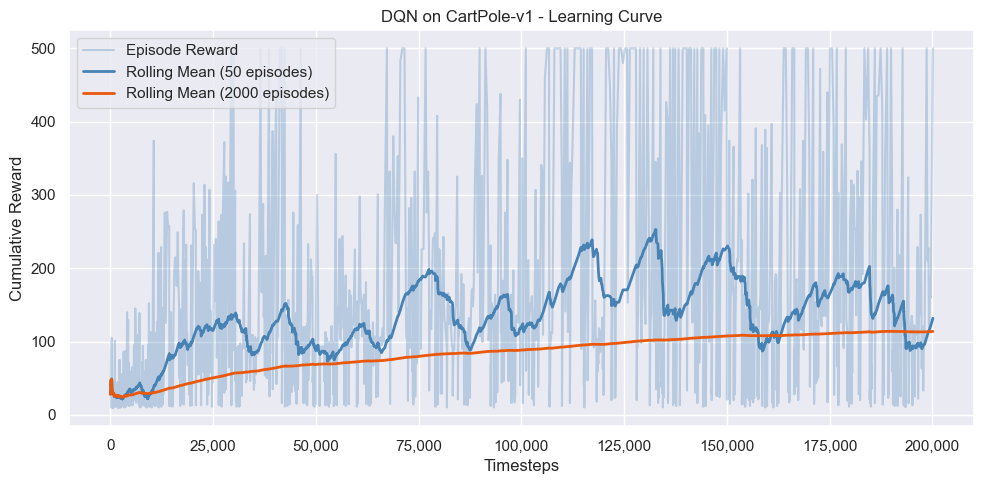

Comparative learning curve: LunarLander-v3 | DQN | 15255 episodes
Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/LunarLander-v3_DQN_comparative_learning_curve.png


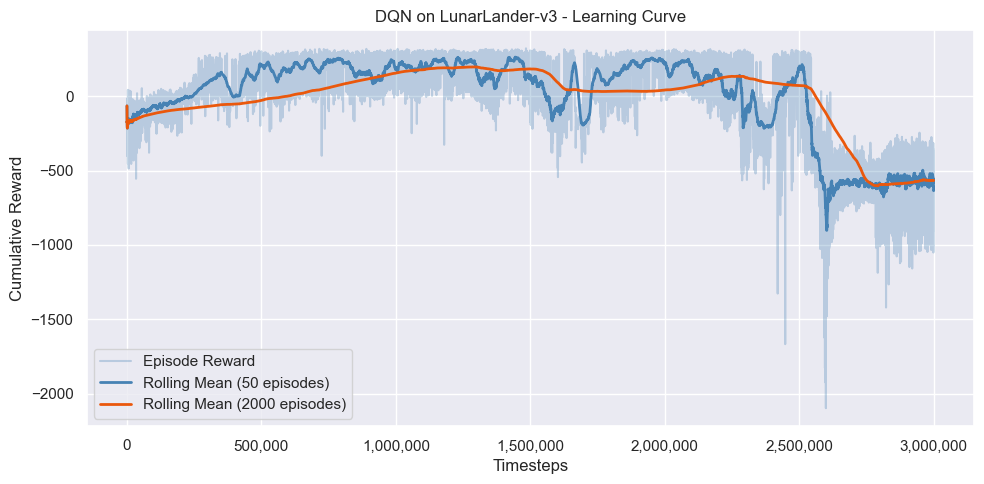

Comparative learning curve: MiniGrid-Empty-5x5-v0 | DQN | 39115 episodes
Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/MiniGrid-Empty-5x5-v0_DQN_comparative_learning_curve.png


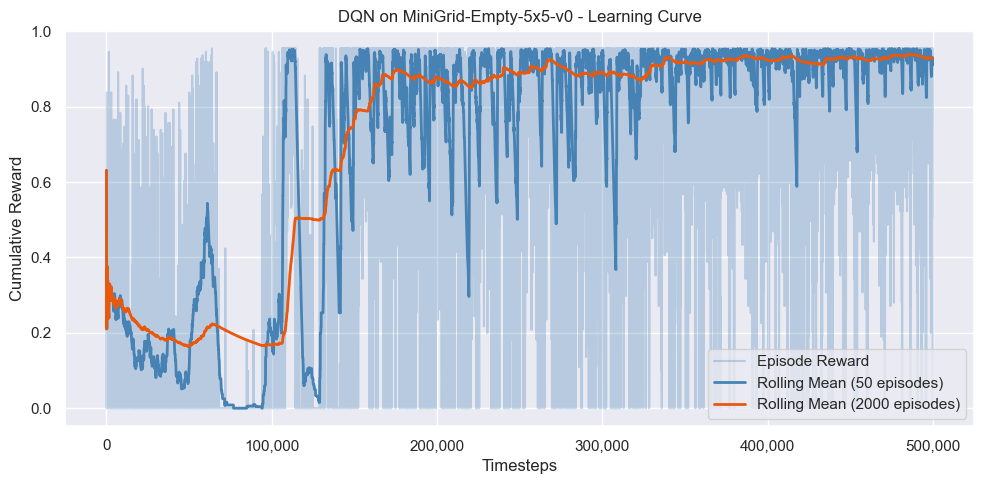

Comparative learning curve: MiniGrid-Empty-5x5-v0 | QLearning | 2000 episodes
Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/MiniGrid-Empty-5x5-v0_QLearning_comparative_learning_curve.png


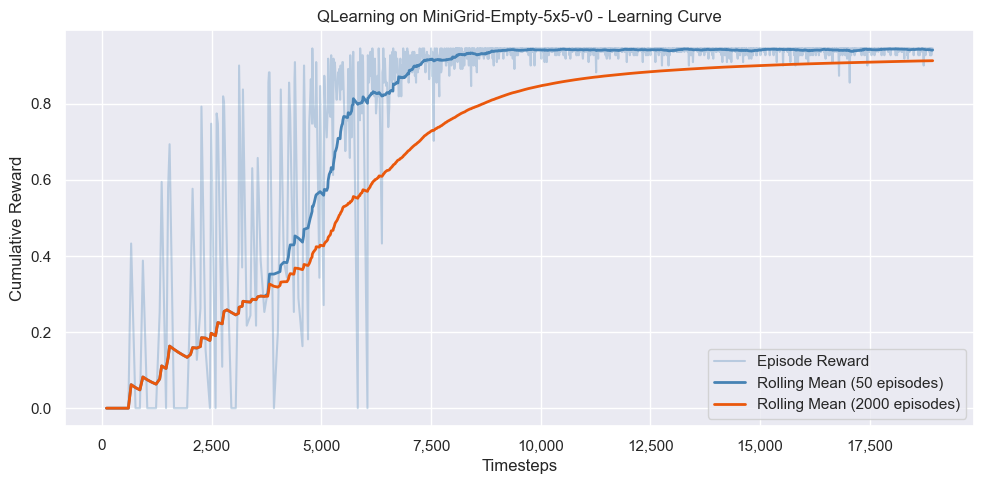

In [18]:
# Section 8.1: comparative curves: cumulative timesteps on x, same rolling pattern as plot_learning_curve (Section 3.2).
WINDOW_SHORT = 50
# Long window shared with convergence logic in 8.2; smooths the tail on noisy returns.
WINDOW_LONG = 2000

# Per run: Monitor path under LOG_DIRECTORY, or None to use results CSV (MiniGrid Q-learning).
COMPARISON_SOURCES = [
  ('CartPole-v1', 'DQN', 'cartpole/monitor.csv'),
  ('LunarLander-v3', 'DQN', 'lunarlander/monitor.csv'),
  ('MiniGrid-Empty-5x5-v0', 'DQN', 'minigrid_dqn/monitor.csv'),
  ('MiniGrid-Empty-5x5-v0', 'QLearning', None),
]


def load_episode_series_for_comparison(env_id, agent, monitor_relative):
  """Returns (rewards, episode_lengths) per finished episode — Monitor `r`/`l` or results CSV."""
  if monitor_relative:
    path = os.path.join(LOG_DIRECTORY, monitor_relative)
    if not os.path.isfile(path):
      raise FileNotFoundError(path)
    mon = pd.read_csv(path, comment='#')
    rewards = mon['r'].to_numpy(dtype=float)
    lengths = mon['l'].to_numpy(dtype=float)
    return rewards, lengths
  path = os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  if not os.path.isfile(path):
    raise FileNotFoundError(path)
  df = pd.read_csv(path).sort_values('episode')
  rewards = df['reward'].to_numpy(dtype=float)
  lengths = df['length'].to_numpy(dtype=float)
  return rewards, lengths


def plot_learning_curve_two_windows(rewards, episode_lengths, env_name, agent_name, save=True):
  """
  Plots episode rewards and two rolling means (WINDOW_SHORT and WINDOW_LONG) against cumulative timesteps.
  Saves to RESULTS_DIRECTORY when save=True, same pattern as plot_learning_curve.
  """
  rewards = np.asarray(rewards, dtype=float)
  lengths = np.asarray(episode_lengths, dtype=float)
  x_steps = np.cumsum(lengths)

  rolling_specs = [
    (WINDOW_SHORT, 'steelblue'),
    (WINDOW_LONG, '#ea580c'),
  ]

  fig, ax = plt.subplots()
  ax.plot(x_steps, rewards, alpha=0.3, color='steelblue', label='Episode Reward')
  for window, color in rolling_specs:
    rolling_mean = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
    ax.plot(x_steps, rolling_mean, color=color, linewidth=2,
            label=f'Rolling Mean ({window} episodes)')
  ax.set_xlabel('Timesteps')
  ax.set_ylabel('Cumulative Reward')
  ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:,.0f}'))
  ax.set_title(f'{agent_name} on {env_name} - Learning Curve')
  ax.legend()
  plt.tight_layout()

  if save:
    filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_comparative_learning_curve.png')
    fig.savefig(filename, dpi=150)
    print(f'Figure Saved To: {filename}')
  plt.show()


for env_id, agent, mon_rel in COMPARISON_SOURCES:
  try:
    rewards, lengths = load_episode_series_for_comparison(env_id, agent, mon_rel)
  except FileNotFoundError as err:
    print(f'Skip (file not found): {env_id} | {agent} | {err}')
    continue
  src = os.path.join(LOG_DIRECTORY, mon_rel) if mon_rel else os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  print(f'Comparative learning curve: {env_id} | {agent} | {len(rewards)} episodes')
  plot_learning_curve_two_windows(rewards, lengths, env_id, agent)


### 8.2 Convergence, mean reward, and stability

The next cell uses each run’s results CSV and the same 2000-episode rolling mean as in 8.1 to define convergence, plus late-window reward statistics.

**Mean reward (late)** is the mean of raw rewards over the last `min(2000, n)` episodes (`n` = run length). **Stability** is the standard deviation of raw rewards in that same window (lower means less episode-to-episode scatter).

**Convergence** is the first episode whose 2000-episode rolling mean lies within 5% of a terminal plateau: the mean of that rolling curve over its last 200 episodes (or fewer if the run is short). That reduces false “early” convergence when the smoothed curve spikes and then drifts down. If there are fewer than 2000 episodes, the scan still runs from the start of the series so the row is not empty. The table lists convergence episode index and cumulative environment steps at that episode (`cumsum` of `length`). If the criterion is never satisfied, those entries are not available.

Late mean reward is printed in the table only. The first bar chart shows convergence timesteps with a logarithmic vertical axis so very long runs remain comparable to shorter ones. The second bar chart shows late-window standard deviation (lower is more stable).


=== Comparative metrics (all runs) ===

          Environment      Agent  n_episodes    mean_all   mean_late  stability_std_late  convergence_episode  convergence_timestep
          CartPole-v1        DQN        1759  113.770893  113.770893          123.282490                 1391              149075.0
       LunarLander-v3        DQN       15255 -162.734386 -566.955855          160.068191                11646             2740770.0
MiniGrid-Empty-5x5-v0        DQN       39115    0.880861    0.928158            0.106071                 4820              166874.0
MiniGrid-Empty-5x5-v0 Q-Learning        2000    0.913629    0.913629            0.129187                 2000               18938.0
Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/comparative_convergence_timesteps.png


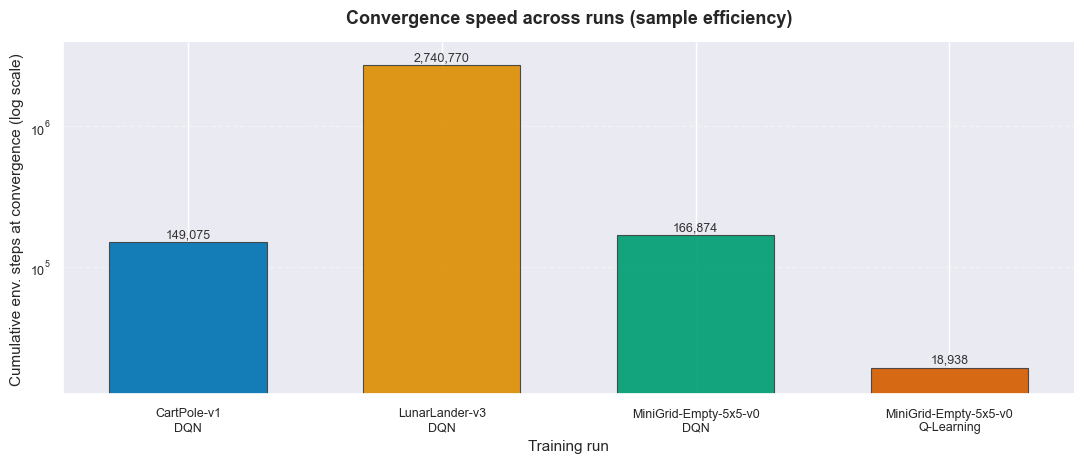

Figure Saved To: /Users/rpglbx/Desktop/RL-gaming-main with GA and reward/results/comparative_stability_std.png


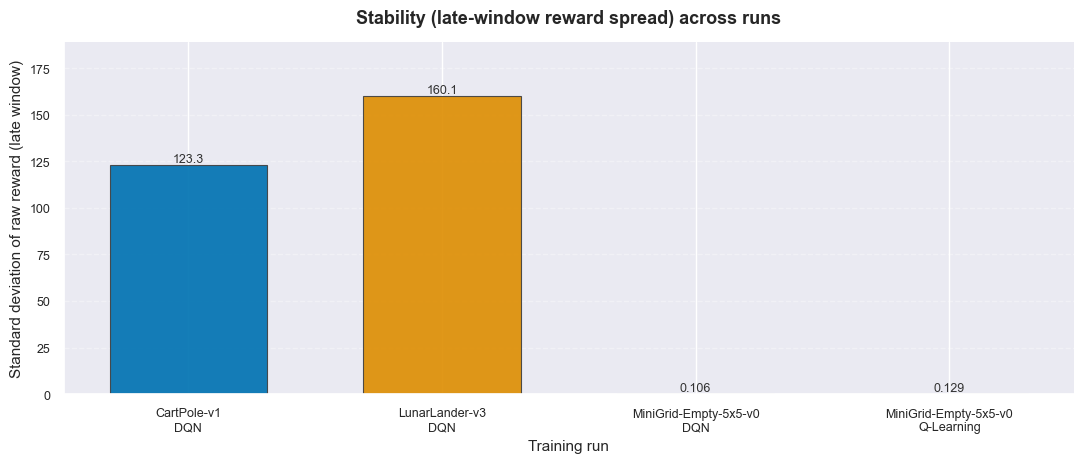

In [19]:
def summarize_run(rewards, episode_lengths, w_long=WINDOW_LONG):
  """
  Summarizes a run from results CSV columns: late-window mean and std, convergence episode and timestep.
  Convergence uses the w_long rolling mean (min_periods=1) and a terminal plateau asymptote (mean of that
  curve over the last plateau_episodes), so a temporary spike does not count as converged.
  """
  s = pd.Series(np.asarray(rewards, dtype=float))
  L = np.asarray(episode_lengths, dtype=float)
  cum_steps = np.cumsum(L)
  n = len(s)
  tail_n = min(w_long, n)
  late_start = n - tail_n
  r_long = s.rolling(window=w_long, min_periods=1).mean()
  late_rewards = s.iloc[late_start:]
  mean_late = float(late_rewards.mean())
  std_late = float(late_rewards.std(ddof=0))
  plateau_episodes = min(200, n)
  asymptote = float(r_long.iloc[-plateau_episodes:].mean())
  tol = 0.05 * max(abs(asymptote), 1e-6)
  conv_ep = np.nan
  conv_step = np.nan
  # Runs shorter than w_long would leave range(w_long - 1, n) empty — no convergence reported.
  start = 0 if n < w_long else w_long - 1
  for i in range(start, n):
    if abs(r_long.iloc[i] - asymptote) <= tol:
      conv_ep = int(i + 1)
      conv_step = float(cum_steps[i])
      break
  return {
    'mean_all': float(s.mean()),
    'mean_late': mean_late,
    'stability_std_late': std_late,
    'convergence_episode': conv_ep,
    'convergence_timestep': conv_step,
    'n_episodes': n,
  }


def display_name(agent):
  return 'Q-Learning' if agent == 'QLearning' else agent


summary_rows = []
for env_id, agent, _ in COMPARISON_SOURCES:
  path = os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  if not os.path.isfile(path):
    print(f'Skip (file not found): {path}')
    continue
  run_df = pd.read_csv(path).sort_values('episode')
  rewards = run_df['reward'].to_numpy()
  lengths = run_df['length'].to_numpy(dtype=float)
  m = summarize_run(rewards, lengths)
  label = f'{env_id}\n{display_name(agent)}'
  summary_rows.append({
    'Run': label,
    'Environment': env_id,
    'Agent': display_name(agent),
    **m,
  })

summary_df = pd.DataFrame(summary_rows)
cols_show = [
  'Environment', 'Agent', 'n_episodes', 'mean_all', 'mean_late',
  'stability_std_late', 'convergence_episode', 'convergence_timestep',
]
print('\n=== Comparative metrics (all runs) ===\n')
print(summary_df[cols_show].to_string(index=False))

# Late mean reward: table only. Two bar charts — convergence timesteps, then late-window std.
run_labels = summary_df['Run'].tolist()
n = len(summary_df)
x = np.arange(n)
bar_colors = sns.color_palette('colorblind', n_colors=max(n, 3))[:n]


def style_metric_figure(ax, ylabel, subtitle):
  ax.set_ylabel(ylabel, fontsize=11)
  ax.set_xlabel('Training run', fontsize=11)
  ax.grid(axis='y', linestyle='--', alpha=0.35)
  ax.set_axisbelow(True)
  sns.despine(ax=ax, top=True, right=True)
  ax.tick_params(axis='x', labelsize=9)
  ax.tick_params(axis='y', labelsize=9)
  ax.set_title(subtitle, fontsize=13, fontweight='semibold', pad=14)


def plot_run_bars(values, ylabel, title, filename, value_fmt, log_y=False):
  fig, ax = plt.subplots(figsize=(11, 4.8))
  vals = np.asarray(values, dtype=float)
  bar_heights = np.where(np.isfinite(vals), vals, np.nan)
  bars = ax.bar(
    x, bar_heights, color=bar_colors, width=0.62,
    edgecolor='0.25', linewidth=0.8, alpha=0.92,
  )
  ax.set_xticks(x)
  ax.set_xticklabels(run_labels)
  finite_vals = vals[np.isfinite(vals)]
  if log_y:
    if finite_vals.size and float(np.min(finite_vals)) > 0:
      ax.set_yscale('log')
      lo = float(np.min(finite_vals))
      hi = float(np.max(finite_vals))
      ax.set_ylim(lo * 0.65, hi * 1.45)
    else:
      ax.set_yscale('log')
  else:
    ymax = float(np.max(finite_vals)) if finite_vals.size else 1.0
    ax.set_ylim(0, ymax * 1.18 if ymax > 0 else 1.0)
  style_metric_figure(ax, ylabel, title)
  ymax_lin = float(np.max(finite_vals)) if finite_vals.size else 1.0
  for bar, v in zip(bars, vals):
    if not np.isfinite(v):
      if log_y and finite_vals.size and float(np.min(finite_vals)) > 0:
        ymin, _ = ax.get_ylim()
        y_note = ymin * 1.08
      else:
        y_note = 0.02 * ymax_lin if ymax_lin > 0 else 0.02
      ax.text(bar.get_x() + bar.get_width() / 2, y_note,
              'n/a', ha='center', va='bottom', fontsize=9, color='0.35')
    else:
      ytxt = bar.get_height()
      ylab = ytxt * 1.04 if log_y else ytxt
      ax.text(bar.get_x() + bar.get_width() / 2, ylab, value_fmt(v),
              ha='center', va='bottom', fontsize=9, fontweight='medium', color='0.2')
  fig.tight_layout()
  out = os.path.join(RESULTS_DIRECTORY, filename)
  fig.savefig(out, dpi=150, bbox_inches='tight')
  print(f'Figure Saved To: {out}')
  plt.show()


conv_steps = summary_df['convergence_timestep'].to_numpy(dtype=float)
conv_plot = np.where(np.isfinite(conv_steps), conv_steps, np.nan)
plot_run_bars(
  conv_plot,
  'Cumulative env. steps at convergence (log scale)',
  'Convergence speed across runs (sample efficiency)',
  'comparative_convergence_timesteps.png',
  lambda v: f'{int(round(v)):,}',
  log_y=True,
)

stab = summary_df['stability_std_late'].to_numpy(dtype=float)
plot_run_bars(
  stab,
  'Standard deviation of raw reward (late window)',
  'Stability (late-window reward spread) across runs',
  'comparative_stability_std.png',
  lambda v: f'{v:.3f}' if abs(v) < 100 else f'{v:.1f}',
)


## **9. Evolutionary Reward Shaping (GA-Based Optimization)**

This section implements a Genetic Algorithm (GA) to optimise reward shaping
functions for reinforcement learning agents.

Unlike the baseline agents (DQN and Q-Learning), which learn directly from
environment-defined rewards, this approach modifies the reward signal itself
using learnable weight parameters.

The goal is to determine whether improved reward shaping can:
- Increase final performance (mean reward)
- Improve learning stability (reduce variance)
- Accelerate convergence speed

The GA operates on a population of reward-weight vectors and evaluates each
individual by reshaping recorded baseline trajectories stored in CSV logs.


### 9.1 Load Baseline Results

In [30]:
def load_results(env_name, agent="DQN"):
    path = os.path.join(RESULTS_DIRECTORY, f"{env_name}_{agent}_results.csv")
    df = pd.read_csv(path)
    return df

### 9.2 Reward Shaping Overview

*TODO: Add description of the reward shaping approach and how it connects the baseline results to the GA optimisation.*

In [60]:
def cartpole_reward(reward, info, w):
    w1, w2 = w
    return w1 * reward - w2 * abs(reward)


def lunar_reward(reward, info, w):
    w1, w2 = w
    return w1 * reward - w2 * (reward ** 2)


def minigrid_reward(reward, info, w):
    w1, w2 = w
    return w1 * reward - w2

### 9.3 Reward Shaping Functions
These reward functions define how GA individuals reshape baseline rewards.

Each chromosome represents a vector of weights applied to different aspects
of the environment reward signal.

This allows the GA to search for reward transformations that improve learning
signals without modifying the underlying RL algorithm.


In [61]:
class RewardWrapper(gym.Wrapper):


    def __init__(self, env, reward_fn, weights):
        super().__init__(env)
        self.reward_fn = reward_fn
        self.weights = weights

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # reshape reward using GA chromosome
        shaped_reward = self.reward_fn(reward, obs, self.weights)

        return obs, shaped_reward, terminated, truncated, info

### 9.4 Fitness Function
These reward functions define how GA individuals reshape baseline rewards.

Each chromosome represents a vector of weights applied to different aspects
of the environment reward signal.

This allows the GA to search for reward transformations that improve learning
signals without modifying the underlying RL algorithm.

In [67]:
def make_env(env_name, reward_fn, weights):

    # IMPORTANT: MiniGrid needs FlatObsWrapper
    if "MiniGrid" in env_name:
        env = gym.make(env_name)
        env = FlatObsWrapper(env)   # 🔥 CRITICAL FIX
    else:
        env = gym.make(env_name)

    env = RewardWrapper(env, reward_fn, weights)
    env = Monitor(env)

    return env

In [50]:
def compute_fitness(episode_rewards):

    rewards = np.array(episode_rewards)

    mean_reward = np.mean(rewards)
    stability = -np.std(rewards)

    # convergence proxy: how fast good rewards appear
    threshold = 0.9 * np.max(rewards)
    indices = np.where(rewards >= threshold)[0]

    if len(indices) > 0:
        convergence = -indices[0]
    else:
        convergence = -len(rewards)

    return mean_reward + 0.5 * stability + 0.1 * convergence

In [64]:
def evaluate_fitness(chromosome, env_name, reward_fn):
    """
    Train a DQN agent under a shaped reward function
    and return learning performance as fitness.
    """

    env = make_env(env_name, reward_fn, chromosome)

    model = DQN(
        "MlpPolicy",
        env,
        verbose=0,
        learning_rate=1e-3,
        buffer_size=20_000,
        learning_starts=500,
        batch_size=32,
        gamma=0.99,
        train_freq=4,
        target_update_interval=500,
    )

    # VERY IMPORTANT: keep small for GA speed
    TIMESTEPS = 2000

    model.learn(total_timesteps=TIMESTEPS)

    env.close()

    # fitness signal = performance proxy
    rewards = env.get_episode_rewards() if hasattr(env, "get_episode_rewards") else []

    if len(rewards) == 0:
        return -1000  # failed run penalty

    rewards = np.array(rewards)

    mean_reward = np.mean(rewards)
    stability = -np.std(rewards)

    return mean_reward + 0.5 * stability

### 9.5 Genetic Algorithm

This section defines the core components of the Genetic Algorithm (GA).

The Genetic Algorithm has a few operation and is used to optimise reward-shaping parameters that influence how
reinforcement learning agents perceive rewards.

* Population Initialisation initialises a population of candidate solutions. Each individual is a vector of continuous values sampled uniformly between -1 and 1. These values represent reward-shaping parameters.

* Selection chooses the best individuals from the current population. A simple elitist selection strategy is used where the top 2 individuals
based on fitness are selected as parents.

* Crossover combines two parent solutions to produce a new offspring. A weighted interpolation is used to mix parent genes, allowing smooth
exploration of the search space.

* Mutation introduces randomness into the population to maintain diversity and prevent premature convergence. Each gene has a probability of being perturbed by Gaussian noise.


Each individual in the population represents a vector of continuous parameters
that modify the reward signal. The goal is to evolve parameters that improve:
- learning stability
- final performance
- convergence speed

In [74]:
POP_SIZE = 6        # reduced for computation
GENERATIONS = 50     # reduced for feasibility
MUTATION_RATE = 0.2

np.random.seed(42)
random.seed(42)

def init_population(dim):
    return [np.random.uniform(-1, 1, dim) for _ in range(POP_SIZE)]


def mutate(ind):
    ind = ind.copy()
    for i in range(len(ind)):
        if np.random.rand() < MUTATION_RATE:
            ind[i] += np.random.normal(0, 0.1)
    return ind


def crossover(p1, p2):
    alpha = np.random.rand()
    return alpha * p1 + (1 - alpha) * p2


def select(pop, fitnesses):
    idx = np.argsort(fitnesses)[-2:]
    return pop[idx[0]], pop[idx[1]]

This function runs the Genetic Algorithm for a given environment.

For each generation:
1. Evaluate population using reward-shaping functions
2. Compute fitness based on shaped rewards
3. Select best individuals
4. Generate next population using crossover + mutation

The process evolves reward parameters that improve reinforcement learning
performance indirectly through reward transformation.

In [65]:
def run_ga(env_name):

    if env_name == "CartPole-v1":
        dim = 2
        reward_fn = cartpole_reward
    elif env_name == "LunarLander-v3":
        dim = 2
        reward_fn = lunar_reward
    else:
        dim = 2
        reward_fn = minigrid_reward

    population = init_population(dim)
    history = []

    for gen in range(GENERATIONS):

        fitnesses = []

        print(f"\nGeneration {gen+1}/{GENERATIONS} - {env_name}")

        for i, ind in enumerate(population):

            fit = evaluate_fitness(ind, env_name, reward_fn)
            fitnesses.append(fit)

            print(f"  Individual {i+1}/{POP_SIZE}: {fit:.2f}")

        best_fit = max(fitnesses)
        history.append(best_fit)

        print(f"Best Fitness: {best_fit:.2f}")

        # selection
        p1, p2 = select(population, fitnesses)

        # new population
        new_pop = []
        while len(new_pop) < POP_SIZE:
            child = crossover(p1, p2)
            child = mutate(child)
            new_pop.append(child)

        population = new_pop

    best_idx = np.argmax(fitnesses)

    return population[best_idx], history

Evaluating the GA across all environments to test generalisation of
reward-shaping optimisation.

In [75]:
best_cp, hist_cp = run_ga("CartPole-v1")
best_ln, hist_ln = run_ga("LunarLander-v3")
best_mg, hist_mg = run_ga("MiniGrid-Empty-5x5-v0")


Generation 1/50 - CartPole-v1
  Individual 1/6: -16.60
  Individual 2/6: 2.14
  Individual 3/6: 0.00
  Individual 4/6: -29.32
  Individual 5/6: -4.59
  Individual 6/6: -26.81
Best Fitness: 2.14

Generation 2/50 - CartPole-v1
  Individual 1/6: -0.85
  Individual 2/6: 3.19
  Individual 3/6: 0.26
  Individual 4/6: 1.72
  Individual 5/6: 1.15
  Individual 6/6: 2.60
Best Fitness: 3.19

Generation 3/50 - CartPole-v1
  Individual 1/6: 2.90
  Individual 2/6: 3.99
  Individual 3/6: 2.65
  Individual 4/6: 2.98
  Individual 5/6: 3.80
  Individual 6/6: 3.08
Best Fitness: 3.99

Generation 4/50 - CartPole-v1
  Individual 1/6: 3.85
  Individual 2/6: 3.02
  Individual 3/6: 4.85
  Individual 4/6: 3.73
  Individual 5/6: 1.02
  Individual 6/6: 4.34
Best Fitness: 4.85

Generation 5/50 - CartPole-v1
  Individual 1/6: 4.93
  Individual 2/6: 4.24
  Individual 3/6: 4.58
  Individual 4/6: 4.16
  Individual 5/6: 4.58
  Individual 6/6: 3.90
Best Fitness: 4.93

Generation 6/50 - CartPole-v1
  Individual 1/6: 4.9

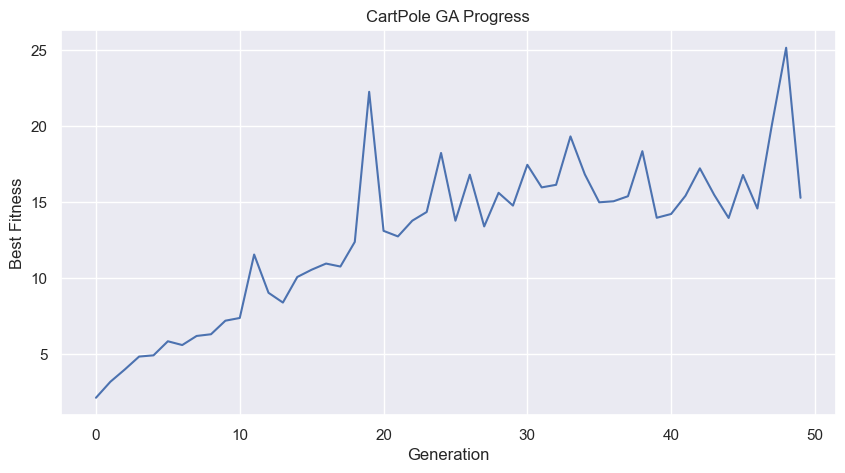

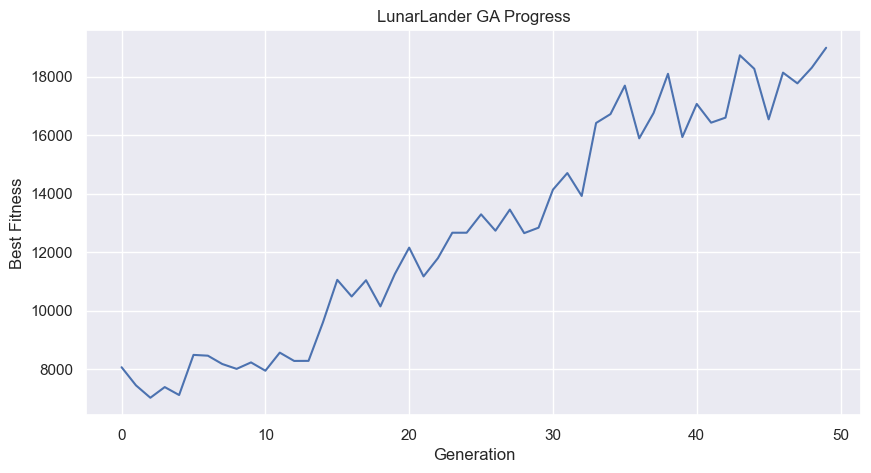

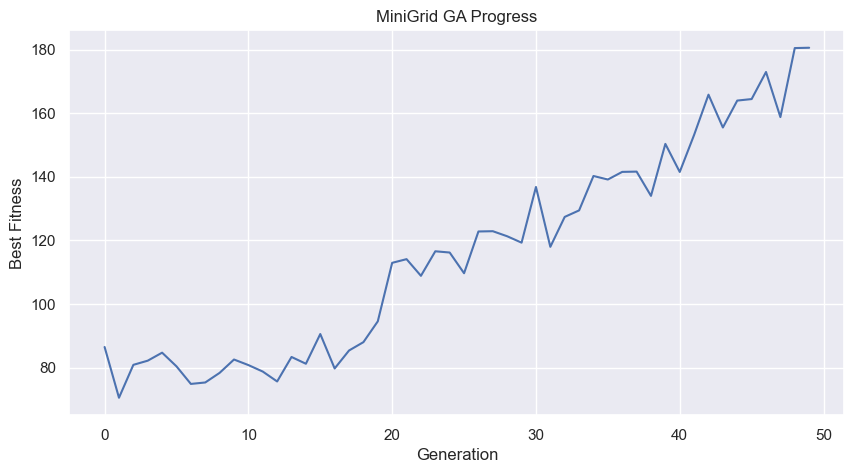

In [76]:
def plot_ga(history, title):
    plt.figure()
    plt.plot(history)
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title(title)
    plt.show()


plot_ga(hist_cp, "CartPole GA Progress")
plot_ga(hist_ln, "LunarLander GA Progress")
plot_ga(hist_mg, "MiniGrid GA Progress")